# Wildfire Prediction

## Table of content

- Read data

- Exploratory data analysis
    - Class balance
    - FWI histograms
    - PCA
    - Missing values

- Feature engineering
    - Train/test split

- Train models
    - Random Forest

- Evaluate
    - ROC
    - confusion matrix
    - feature importance

## Read data

### Libraries

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scripts.s00_set_parameters import PARAMETERS
from typing import Any


### Load data

In [2]:
fname_ml         = "2026-07-12_ml_input.csv"
dir_sampled_data = PARAMETERS['DATA_DIR']/"MLInputs"/fname_ml
df_ml            = pd.read_csv(dir_sampled_data, dtype={"composite_key": "string", 
                                                        "composite_key_y": "string", 
                                                        "bridge_composite_key_y": "string"},
                                                 parse_dates = ["date_y", "date"] )
df_ml.head()

,composite_key_y,grid_id_y,sample_type_y,date_y,fire_lbl_y,bridge_composite_key_y,grid_id,x_coord,y_coord,geometry,...,feat_502,feat_503,feat_504,feat_505,feat_506,feat_507,feat_508,feat_509,feat_510,feat_511
0,220180406,2,fire,2018-04-06,True,220180405,2.0,150000.0,30000.0,POLYGON ((-5.578238327280583 50.06090231842405...,...,0.000000,0.525944,0.000000,0.766935,0.489491,0.000000,0.000000,0.444547,0.000000,0.000000
1,420180506,4,fire,2018-05-06,True,420180505,4.0,174000.0,30000.0,POLYGON ((-5.2435028953546645 50.0707501119652...,...,0.000000,0.268171,0.000000,0.422897,0.479971,0.120014,0.000000,1.500003,0.007276,0.000000
2,420181010,4,fire,2018-10-10,True,420181009,4.0,174000.0,30000.0,POLYGON ((-5.2435028953546645 50.0707501119652...,...,0.219416,0.518395,0.000000,2.066457,0.970331,0.000000,0.000000,0.619320,0.290066,0.000000
3,820180412,8,fire,2018-04-12,True,820180411,8.0,270000.0,42000.0,POLYGON ((-3.9072676952681493 50.2083487953191...,...,0.020261,0.000000,0.000000,2.690465,0.443573,0.000000,0.000000,0.031737,0.781908,0.000000
4,920180712,9,fire,2018-07-12,True,920180711,9.0,174000.0,54000.0,POLYGON ((-5.258143121215753 50.28624666109973...,...,0.008278,0.028806,0.014081,0.290681,2.811433,0.078962,1.842476,1.287925,0.000000,0.410075


## Exploratory data analysis

### Data structure

The full dataset contains the columns below. All the columns that end with suffix `y` refer to be values to be predicted. These are the values that the model needs to predict. The rest of the columns contain the data to train the model. The training data (non `y` columns) are from a t-1 from value to predict. 

In [71]:
print(df_ml.columns)
print(df_ml.dtypes)

Index(['composite_key_y', 'grid_id_y', 'sample_type_y', 'date_y', 'fire_lbl_y',
       'bridge_composite_key_y', 'grid_id', 'x_coord', 'y_coord', 'geometry',
       ...
       'feat_502', 'feat_503', 'feat_504', 'feat_505', 'feat_506', 'feat_507',
       'feat_508', 'feat_509', 'feat_510', 'feat_511'],
      dtype='str', length=530)
composite_key_y            string
grid_id_y                   int64
sample_type_y                 str
date_y             datetime64[us]
fire_lbl_y                   bool
                        ...      
feat_507                  float64
feat_508                  float64
feat_509                  float64
feat_510                  float64
feat_511                  float64
Length: 530, dtype: object


In [74]:
for row in df_ml.itertuples():
    row: Any
    days_diff = (row.date_y - row.date).days
    if days_diff != 1:
        print('❌ Date assumption of t-1 not met!')
print(f"✅ t-1 assumption validated [{df_ml.shape[0]} rows checked]")

✅ t-1 assumption validated [38204 rows checked]


### Class balance

The sampling procedure implemented a 2:1 no-fire to fire ratio when selecting the samples. The reason of this is that no-fire events are much more common than fire events. However, using the real distribution would have produced an extremely imbalanced dataset. To mitigate this, a 2:1 ratio was implemented to maintain the frequency property but reducing the class imbalance to a more manageable state, as done by previous studies. 

The complete details of the sampling procedure are in:
- Functions: `src/sampling/sampling_functions.py` 
- Pipeline: `src/pipelines/sampling_pipeline.py`

In [5]:
df_ml['fire_lbl_y'].value_counts(normalize=True)

fire_lbl_y
False    0.614412
True     0.385588
Name: proportion, dtype: float64

### FWI Distribution

The Fire Weather Index is used as a predictor variable in the model. The histogram below compares the distribution of FWI values for fire and no-fire classes.

The class imbalance in the predictor variable is evident, with only 1,816 fire observations vs 36,388 no-fire observations.

However, the descriptive statistics show that the fire class has consistently higher FWI values than the no fire, with the median of fire observations almost 3 times higher than the no-fire counterpart. It is worth nothing, however, that the max value of no-fire is greater than the fire (more than 2sd above the max). This is the case for 7/36388 of the no-fire observations, which indicates these are rate events

In [34]:
df_fwi_descriptives = df_ml[['fwi_mean', 'fire_lbl']].groupby('fire_lbl').describe()
df_fwi_descriptives

fwi_mean                                                        \
            count      mean       std           min       25%       50%   
fire_lbl                                                                  
False     36388.0  3.620400  5.880850  1.721512e-09  0.257813  0.914331   
True       1816.0  5.732212  7.466659  1.724128e-09  0.690369  2.551709   

                               
               75%        max  
fire_lbl                       
False     4.617249  68.532227  
True      7.889746  50.774902

In [45]:
# Count of no fire observations above the max of Fire
fwi_fire_lbl_max = df_fwi_descriptives.loc[True, ("fwi_mean", "max")]
df_ml[ (df_ml['fire_lbl'] == False) & (df_ml['fwi_mean'] > fwi_fire_lbl_max)].shape[0]

7

The histogram shows a greater concentration of no fire observations for FWI values close to zero. As FWI increases, the concentration of fire observations becomes greater than no fire 

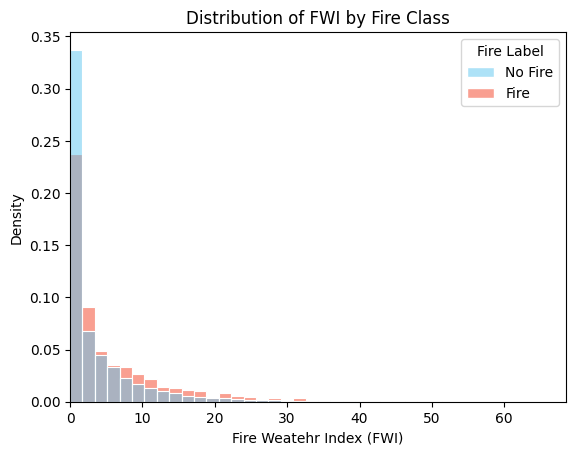

In [68]:

sns.histplot(data=df_ml, 
             x= 'fwi_mean', 
             hue = 'fire_lbl', 
             bins = 40, 
             stat = 'density', 
             common_norm = False,
             alpha = 0.5,
             palette = {False:"#5CC6F0",
                        True: "#F54125" },
              edgecolor = 'white')
plt.title("Distribution of FWI by Fire Class")
plt.xlabel("Fire Weatehr Index (FWI)")
plt.ylabel("Density")

plt.xlim(0, df_ml['fwi_mean'].max())

ax = plt.gca()
legend = ax.get_legend()
if legend is not None:
    legend.set_title("Fire Label")
    legend.texts[0].set_text("No Fire")
    legend.texts[1].set_text("Fire")

<Axes: xlabel='fwi_mean', ylabel='Density'>

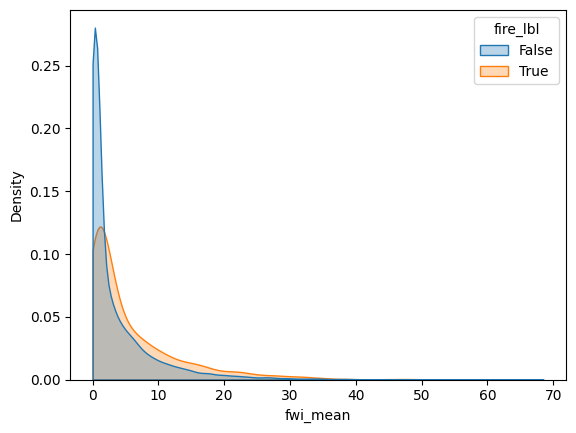

In [23]:
sns.kdeplot(
    data=df_ml,
    x="fwi_mean",
    hue="fire_lbl",
    fill = True,
    common_norm=False,
    alpha=0.3,
    cut = 0,
    clip = (0, None)
)

## Feature engineering

### Train/Test split

In [97]:
year_dict = {}
for row in df_ml.itertuples():
    row: Any
    year_str = str(row.date.year)
    year_dict[year_str] = year_dict.get(year_str, 0) + 1

print(f"Total rows {df_ml.shape[0]}")
print(year_dict)

Total rows 38204
{'2018': 7337, '2019': 6695, '2020': 5202, '2021': 5612, '2022': 6165, '2023': 4065, '2024': 3128}


In [121]:
def train_test_temporal_split(df_in: pd.DataFrame, sort_col:str = 'date', train_size: float = 0.7):

    if train_size >= 1 or train_size <=0:
        raise ValueError("ERROR Train size must be >0 and <1 as this represents a proportion")
    
    df = df_in.sort_values(by = [sort_col])
    
    split_idx = int(len(df) * train_size)

    train_df = df.iloc[:split_idx]
    test_df  = df.iloc[split_idx:]

    return train_df, test_df

In [129]:
import re

sentinel_feat_cols = [c for c in df_ml.columns if re.search("^feat_", c)]

# Preapre data
df_train, df_test = train_test_temporal_split(df_ml)

y_train = df_train.loc[:, 'fire_lbl_y']
y_test = df_test.loc[:, 'fire_lbl_y']

X_train_fwi = df_train.loc[:, ['fwi_mean']]
X_test_fwi = df_test.loc[:, ['fwi_mean']]

X_train_sentinel = df_train.loc[:, sentinel_feat_cols]
X_test_sentinel = df_test.loc[:, sentinel_feat_cols]

hybrid_cols = sentinel_feat_cols + ['fwi_mean']

X_train_hybrid = df_train.loc[:, hybrid_cols]
X_test_hybrid = df_test.loc[:, hybrid_cols]

